---
title: "Shock Absorber"
format: 
    html: 
        toc: true
execute: 
  enabled: true
bibliography: "../../references.bib"
jupyter: python3
---

Here, we characterise the posterior distribution associated with a model of the time to failure for a shock absorber.

# Problem Setup

We consider the problem of estimating the parameters of a model of the time to failure for a type of shock absorber. For further information on the model, see @Dolgov2020 and the references therein.

We will use an accelerated failure time Weibull regression model, in which the density of the distance to failure of a given shock absorber is given by

$$
f(t | \theta_{1}, \theta_{2}) = \frac{\theta_{2}}{\theta_{1}}\left(\frac{t}{\theta_{1}}\right)^{\theta_{2}-1}\exp\left(-\left(\frac{t}{\theta_{1}}\right)^{\theta_{2}}\right),
$$

where $\theta_{1} >0$ is a scale parameter and $\theta_{2} > 0$ is a shape parameter. The scale parameter, $\theta_{1}$, depends on a set of $D$ covariates, $\boldsymbol{x} := [x_{1}, x_{2}, \dots, x_{D}]^{\top}$ (which are specific to each shock absorber) through the standard logarithmic link function:

$$
\theta_{1}(\boldsymbol{\beta}) = \exp\left(\beta_{0} + \sum_{i=1}^{D}\beta_{i}x_{i}\right),
$$

where $\boldsymbol{\beta} := [\beta_{0}, \beta_{1}, \dots, \beta_{D}]^{\top}$ denote a set of unknown parameters.

## Likelihood Function

To estimate the unknown parameters, we use a dataset of 38 failure distances, $\boldsymbol{t} := [t_{1}, t_{2}, \dots, t_{38}]^{\top}$, some of which are subject to right censoring. We assume that these measurements are independent, which means that the likelihood takes the form

$$
\mathcal{L}(\boldsymbol{\beta}, \theta_{2}; \boldsymbol{t}) = \prod_{i=1}^{38} P(t_{i} | \theta_{1}(\boldsymbol{\beta}), \theta_{2}),
$$

where 

$$
P(t_{i} | \theta_{1}, \theta_{2}) = \begin{cases}
    f(t_{i} | \theta_{1}, \theta_{2}), & \textrm{if } t_{i} \textrm{ is not censored}, \\
    \exp\left(-\left(\frac{t_{i}}{\theta_{1}}\right)^{\theta_{2}}\right), & \textrm{if } t_{i} \textrm{ is censored}.
\end{cases}
$$

The value for the right censored case is the probability that the failure time is greater than or equal to the observed value.

## Prior Density

As a prior, we use a normal-gamma density [see, *e.g.*, @Koch2007], which takes the form 

$$
\pi_{0}(\boldsymbol{\beta}, \theta_{2}) \propto \theta_{2}^{D/2+\alpha} \exp(-\gamma\theta_{2}) \prod_{i=0}^{D} \exp\left(-\frac{\theta_{2}(\beta_{i}-m_{i})^{2}}{2\sigma_{i}^{2}}\right),
$$

where $\gamma = 2.2932$, $\alpha = 6.8757$, $m_{0} = \log(30796)$, $m_{1} = \cdots = m_{D} = 0$, $\sigma_{0}^{2} = 0.1563$, and $\sigma_{1} = \cdots = \sigma_{D} = 1$.

Note that, with this choice for prior, the marginal density for $\theta_{2}$ is a gamma density; that is, $\theta_{2} \sim \mathrm{Gamma}(\gamma, \alpha)$. The conditional density for each coefficient $\beta_{i}$ is a normal density with a variance depending on $\theta_{2}$; that is, $\beta_{i} | \theta_{2} \sim \mathcal{N}(m_{i}, \sigma^{2}_{i}/\theta_{2})$.

# Implementation in $\texttt{deep\_tensor}$

We begin by importing the relevant libraries and reading in the failure distance data.

In [1]:
import math
from pathlib import Path

from matplotlib import pyplot as plt
import torch
from torch import Tensor

import deep_tensor as dt

from examples.plotting import add_arrows, set_plot_style
from examples.shock import GammaNormalMapping, load_shock_data

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.set_default_device(device)
torch.manual_seed(0)

plot_path = Path().parent.joinpath("plots")
set_plot_style()

In [3]:
data = load_shock_data(device)
failure_dists, censored = data.failure_dists, data.censored

Next, we define a function which evaluates the negative logarithm of (a quantity proportional to) the posterior density.

In [ ]:
def _eval_neglogpost(params: Tensor, xs: Tensor) -> Tensor:

    bs, t2s = params[:, :-1], params[:, -1:]

    # Compute theta_1 values
    bxs = torch.sum(bs[:, 1:, None] * xs.T[None, :, :], dim=1)
    t1s = torch.exp(bs[:, :1] + bxs)

    # Add contribution of uncensored failure times
    neglogliks = (
        -torch.log(t2s / t1s[:, ~data.censored]) 
        - (t2s - 1.0) * torch.log(failure_dists[~censored] / t1s[:, ~censored]) 
        + (failure_dists[~censored] / t1s[:, ~censored]) ** t2s
    ).sum(dim=1)
    
    # Add contribution of censored failure times
    neglogliks += (
        (failure_dists[censored] / t1s[:, censored]) ** t2s
    ).sum(dim=1)

    neglogpris = (
        - (0.5*D + alpha) * t2s.log().flatten()
        + gamma * t2s.flatten()
        + 0.5 * torch.sum(t2s * (bs-ms)**2 / sds**2, dim=1)
    )
    
    neglogposts = neglogliks + neglogpris
    return neglogposts

In [5]:
# Define prior coefficients
alpha = torch.tensor(6.8757)
gamma = torch.tensor(2.2932)

In [6]:
# Define options for constructing EFTT approximations
eftt_pod_options = dt.EFTTOptions(fibre_method="random", tol_svd=1e-2, num_snapshots=50)
eftt_aca_options = dt.EFTTOptions(fibre_method="aca", tol_aca=1e-3, num_aca=100)

# Define parameters common to all DIRT approximations
basis = dt.Lagrange1(num_elems=29)
reference = dt.GaussianReference()
bridge = dt.SingleLayer()
dirt_options = dt.DIRTOptions(verbose=0)

## (E)FTT Comparison: Varying Dimensions

We begin by varying the number of covariates, $D$, which has the effect of changing the dimension of the posterior (which is given by $D+2$), and comparing the accuracy of DIRT approximations to the posterior constructed using:
 - a standard FTT approximation;
 - an EFTT approximation with reduced bases constructed using the proper orthogonal decomposition (POD); and
 - an EFTT approximation with reduced bases constructed using adaptive cross approximation (ACA).

In [7]:
ftts = ["FTT", "EFTT (POD)", "EFTT (ACA)"]

# Define parameters used when constructing TT approximations
tt_options = dt.TTOptions(tt_method="amen", max_als=2, init_rank=8, verbose=0)

In [8]:
# Initialise list of numbers of covariates to iterate over
Ds = torch.tensor([2, 4, 6, 8, 10, 12, 14]) 

num_replications = 10

dhells = torch.zeros((len(Ds), num_replications, len(ftts)))
evals = torch.zeros((len(Ds), num_replications, len(ftts)))
max_tuckers = torch.zeros((len(Ds), num_replications, len(ftts)))

In [9]:
for i, D in enumerate(Ds):

    D = int(D)
    dim = D + 2

    # Define (dimension-dependent) means and standard deviations of 
    # beta coefficients
    ms = torch.zeros(D+1)
    ms[0] = math.log(30796)
    sds = torch.ones(D+1)
    sds[0] = math.sqrt(0.1563)

    # Define bounds for parameters
    bounds = torch.zeros((D+2, 2))
    bounds[:-1] = torch.vstack((ms - 3.0*sds, ms + 3.0*sds)).T 
    bounds[-1] = torch.tensor([1e-8, 13.0])

    # Define preconditioner
    preconditioner = GammaNormalMapping(
        reference, bounds, 
        alpha, gamma, 
        ms, sds, dim
    )

    for j in range(num_replications):
        
        # Generate a new random set of covariates
        covariate_shape = (failure_dists.numel(), D)
        xs = torch.randn(covariate_shape) / D

        # Define target function
        eval_neglogpost = lambda params: _eval_neglogpost(params, xs)
        target_func = dt.TargetFunc(eval_neglogpost)

        rs = reference.random(n=5_000, d=dim)

        for k, ftt_name in enumerate(ftts):

            tt = dt.TT(tt_options)

            if ftt_name == "FTT":
                ftt = dt.FTT(basis, tt)
            elif ftt_name == "EFTT (POD)":
                ftt = dt.EFTT(basis, tt, eftt_pod_options)
            elif ftt_name == "EFTT (ACA)":
                ftt = dt.EFTT(basis, tt, eftt_aca_options)
            else:
                raise Exception(f"Unknown FTT type: '{ftt_name}'.")

            dirt = dt.DIRT(
                target_func, preconditioner, ftt, bridge, 
                options=dirt_options
            )

            samples_dirt, potentials_dirt = dirt.eval_irt(rs)

            potentials_true = eval_neglogpost(samples_dirt)

            dhell = dt.compute_f_divergence(-potentials_dirt, -potentials_true).sqrt().item()

            dhells[i][j][k] = dhell 
            evals[i][j][k] = dirt.num_eval_construction
            if isinstance(dirt.sirts[0].ftt, dt.EFTT):
                max_tuckers[i][j][k] = dirt.sirts[0].ftt.basis_dims.max()

We can now plot the results.

In [10]:
# Define shared plotting parameters
colours = ["tab:blue", "tab:red", "tab:green"]

kwargs_errorbar = {
    "fmt": "-o", "markersize": 6, 
    "linewidth": 1.5, "elinewidth": 1.5, 
    "capsize": 3.0, "capthick": 1.5
}

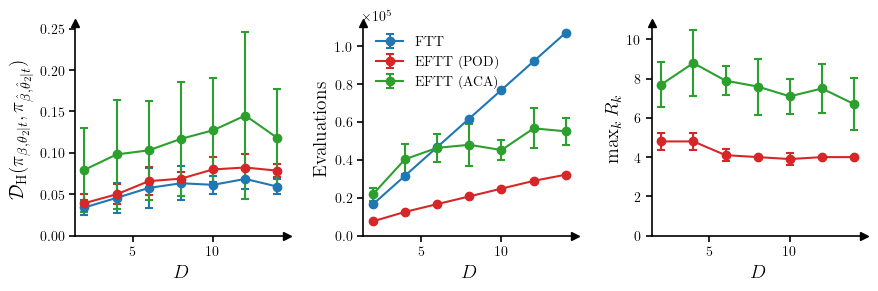

In [11]:
fig, axes = plt.subplots(1, 3, figsize=(9, 3.2))

dhells_mean = dhells.mean(dim=1)
dhells_sd = dhells.std(dim=1)

evals_mean = evals.mean(dim=1)
evals_sd = evals.std(dim=1)

max_tuckers_mean = max_tuckers.mean(dim=1)
max_tuckers_sd = max_tuckers.std(dim=1)

for i in range(len(ftts)):
    axes[0].errorbar(
        Ds, dhells_mean[:, i], yerr=dhells_sd[:, i], 
        label=ftts[i], c=colours[i], **kwargs_errorbar
    )
    axes[1].errorbar(
        Ds, evals_mean[:, i], yerr=evals_sd[:, i], 
        label=ftts[i], c=colours[i], **kwargs_errorbar
    )
    if "EFTT" in ftts[i]:
        axes[2].errorbar(
            Ds, max_tuckers_mean[:, i], yerr=max_tuckers_sd[:, i],
            label=ftts[i], c=colours[i], **kwargs_errorbar
        )

for ax in axes.flat:
    add_arrows(ax)
    ax.set_box_aspect(1)
    ax.set_xlabel(r"$D$")
    ax.set_ylim(bottom=0.0)

axes[0].set_ylabel(r"$\mathcal{D}_{\mathrm{H}}(\pi_{\beta, \theta_{2} | t}, \pi_{\hat{\beta}, \hat{\theta}_{2} | t})$")
axes[1].set_ylabel(r"Evaluations")
axes[2].set_ylabel(r"$\max_{k} R_{k}$")
axes[1].legend(fontsize=10)
axes[1].ticklabel_format(axis="y", scilimits=(0, 0))

plt.tight_layout()

save_path = plot_path.joinpath("dims.pdf").resolve()
plt.savefig(save_path)

## (E)FTT Comparison: Tensor Train Ranks

Next, we fix the number of covariates to $D = 8$ and vary the tensor train ranks. Again, we compare the DIRT approximations to the posterior constructed using:
 - a standard FTT approximation;
 - an EFTT approximation with reduced bases constructed using the proper orthogonal decomposition (POD); and
 - an EFTT approximation with reduced bases constructed using adaptive cross approximation (ACA).

In [12]:
# Fix the number of covariates
D = 8
dim = D + 2

# Define the means and standard deviations of the beta coefficients
ms = torch.zeros(D+1)
ms[0] = math.log(30796)
sds = torch.ones(D+1)
sds[0] = math.sqrt(0.1563)

# Define bounds for parameters
bounds = torch.zeros((D+2, 2))
bounds[:-1] = torch.vstack((ms - 3.0*sds, ms + 3.0*sds)).T 
bounds[-1] = torch.tensor([1e-8, 13.0])

preconditioner = GammaNormalMapping(
    reference, bounds, 
    alpha, gamma, 
    ms, sds, dim
)

# Define ranks to test (these correspond to the max ranks after two ALS 
# iterations using AMEn (kick rank=2))
ranks = [6, 8, 10, 12, 14, 16, 18, 20]

In [13]:
num_replications = 10

dhells = torch.zeros((len(ranks), num_replications, len(ftts)))
evals = torch.zeros((len(ranks), num_replications, len(ftts)))

rs = reference.random(n=5_000, d=dim)

In [14]:
for i, rank in enumerate(ranks):

    for j in range(num_replications):
        
        # Generate covariates
        covariate_shape = (failure_dists.numel(), D)
        xs = torch.randn(covariate_shape) / D

        eval_neglogpost = lambda params: _eval_neglogpost(params, xs)
        target_func = dt.TargetFunc(eval_neglogpost)

        for k, ftt_name in enumerate(ftts):

            tt_options = dt.TTOptions(
                tt_method="amen", max_als=2, init_rank=rank-4, 
                verbose=0
            )
            tt = dt.TT(tt_options)

            if ftt_name == "FTT":
                ftt = dt.FTT(basis, tt)
            elif ftt_name == "EFTT (POD)":
                ftt = dt.EFTT(basis, tt, eftt_pod_options)
            elif ftt_name == "EFTT (ACA)":
                ftt = dt.EFTT(basis, tt, eftt_aca_options)
            else:
                raise Exception(f"Unknown FTT type: '{ftt_name}'.")

            dirt = dt.DIRT(
                target_func, preconditioner, ftt, bridge,
                options=dirt_options
            )

            samples_dirt, potentials_dirt = dirt.eval_irt(rs)

            # Run an independence MCMC sampler
            potentials_true = eval_neglogpost(samples_dirt)

            dhell = dt.compute_f_divergence(-potentials_dirt, -potentials_true).sqrt().item()

            dhells[i][j][k] = dhell 
            evals[i][j][k] = dirt.num_eval_construction

We can now plot the results.

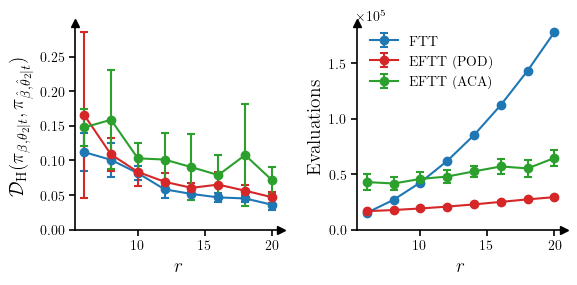

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(6, 3.2))

dhells_mean = dhells.mean(dim=1)
dhells_sd = dhells.std(dim=1)

evals_mean = evals.mean(dim=1)
evals_sd = evals.std(dim=1)

for i in range(len(ftts)):
    axes[0].errorbar(
        ranks, dhells_mean[:, i], yerr=dhells_sd[:, i], 
        label=ftts[i], c=colours[i], **kwargs_errorbar
    )
    axes[1].errorbar(
        ranks, evals_mean[:, i], yerr=evals_sd[:, i], 
        label=ftts[i], c=colours[i], **kwargs_errorbar
    )

for ax in axes.flat:
    add_arrows(ax)
    ax.set_box_aspect(1)
    ax.set_xlabel(r"$r$")
    ax.set_ylim(bottom=0.0)

axes[0].set_ylabel(r"$\mathcal{D}_{\mathrm{H}}(\pi_{\beta, \theta_{2} | t}, \pi_{\hat{\beta}, \hat{\theta}_{2} | t})$")
axes[1].set_ylabel(r"Evaluations")
axes[1].legend(fontsize=10)
axes[1].ticklabel_format(axis="y", scilimits=(0, 0))

plt.tight_layout()

save_path = plot_path.joinpath("ranks.pdf").resolve()
plt.savefig(save_path)